In [ ]:
import os
import ale_py
import pandas as pd
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecMonitor, VecFrameStack
from Helper import render_callback
from Helper import evaluate
from Helper import plot_reward

In [ ]:
env_id = "ALE/Breakout-v5"

log_path = "monitor/Breakout_ppo_monitor.csv"
if os.path.exists(log_path):
    os.remove(log_path)

env = make_atari_env(env_id, n_envs=8, wrapper_kwargs=dict(terminal_on_life_loss=False))
env = VecFrameStack(env, n_stack=4)
env = VecMonitor(env, filename=log_path)

In [ ]:
print(env.action_space)
print(env.observation_space)

In [ ]:
model = PPO(
    policy="CnnPolicy",
    env=env,
    n_steps=128,
    batch_size=256,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    verbose=1,
    device="cuda"
)

model.learn(total_timesteps=1_000_000)

In [ ]:
evaluate(model, env_id)

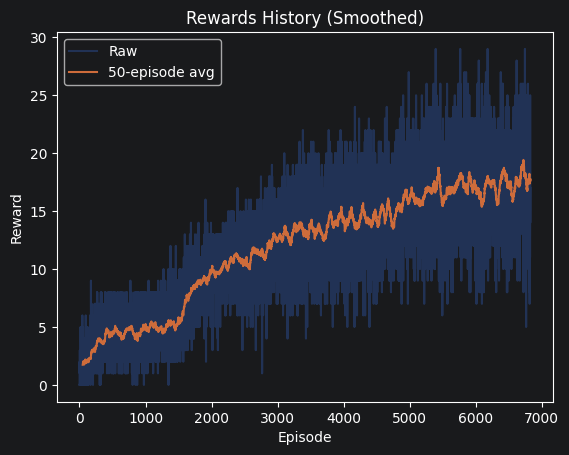

In [8]:
df = pd.read_csv(log_path, skiprows=1)
rewards = df["r"]

plot_reward(rewards)

In [ ]:
model_name = "ppo-Breakout"
model.save(model_name)
# model = PPO.load(model_name)

In [ ]:
render_callback(model, env_id)